In [ ]:
task-1

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

/tmp/ipykernel_1039/3118241580.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1039/3118241580.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

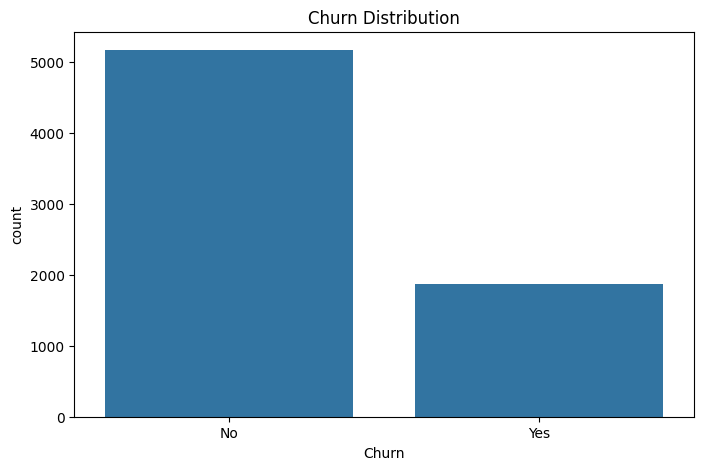

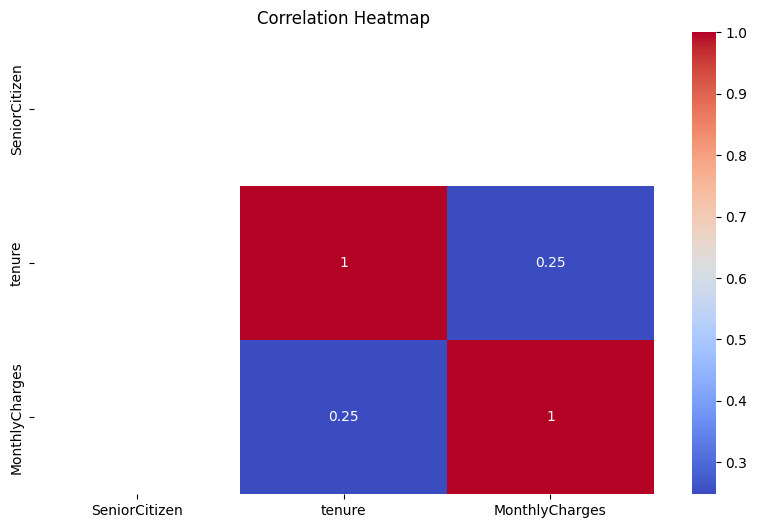

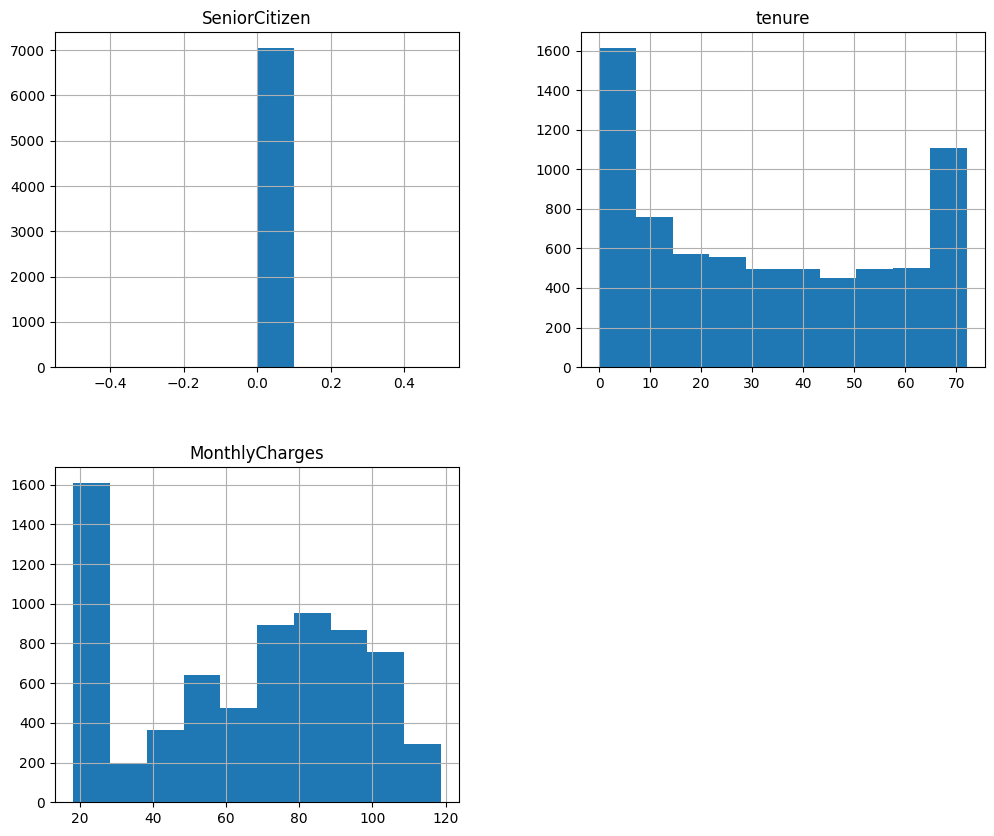

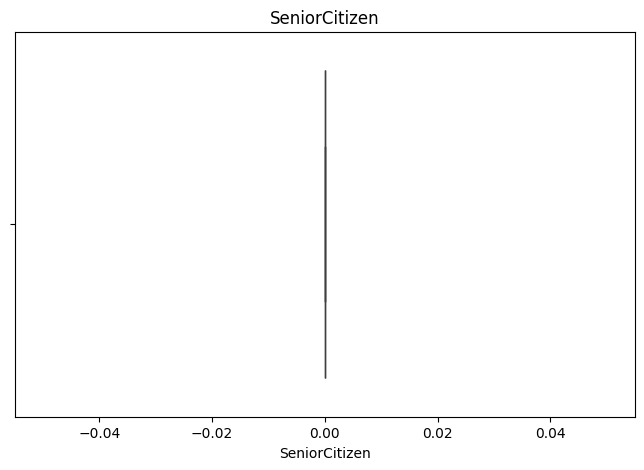

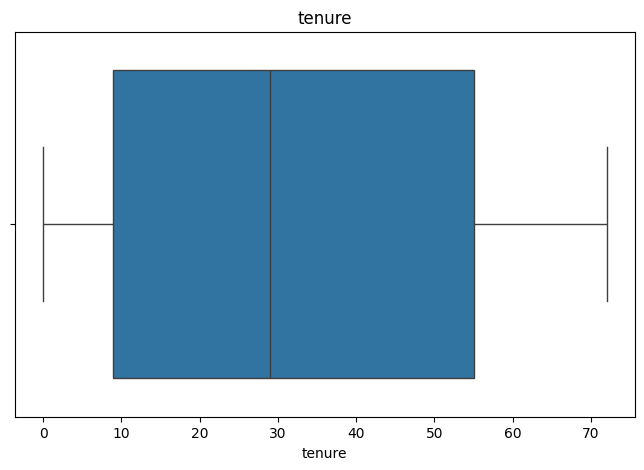

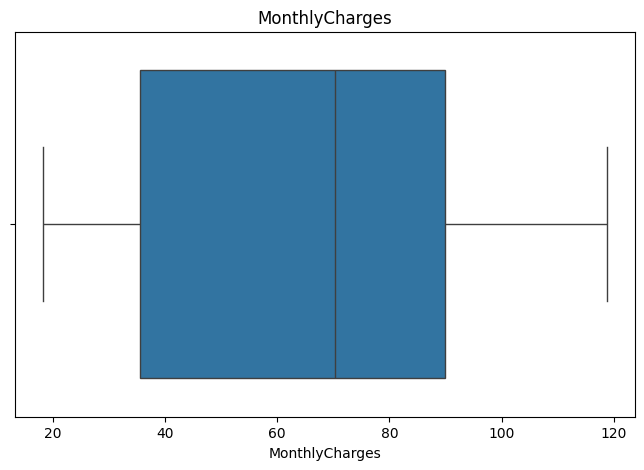

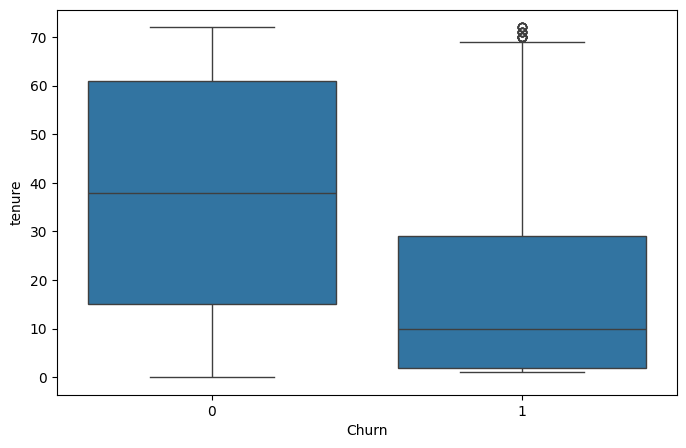

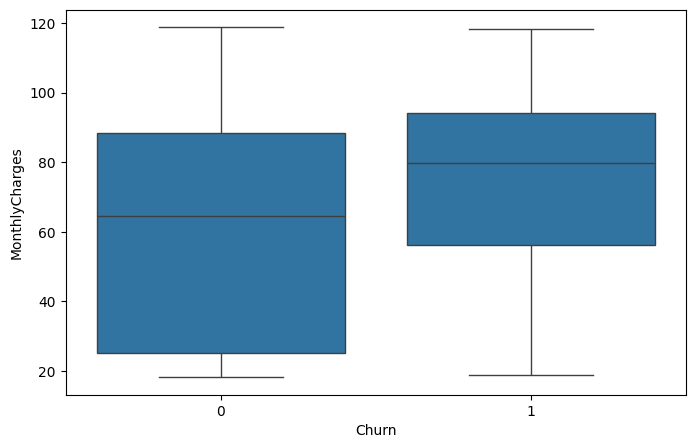

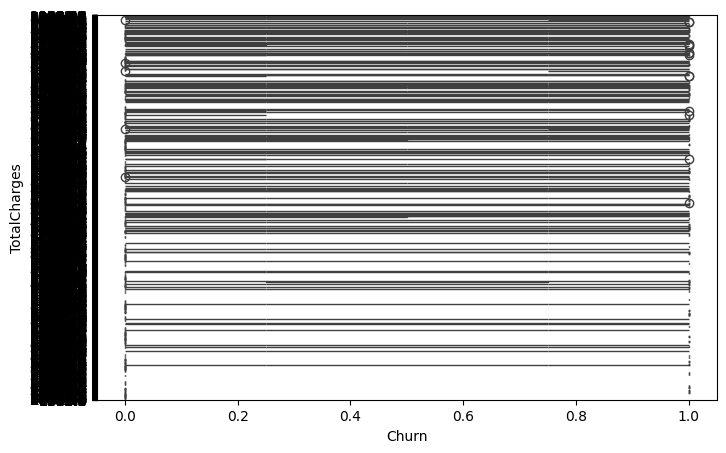

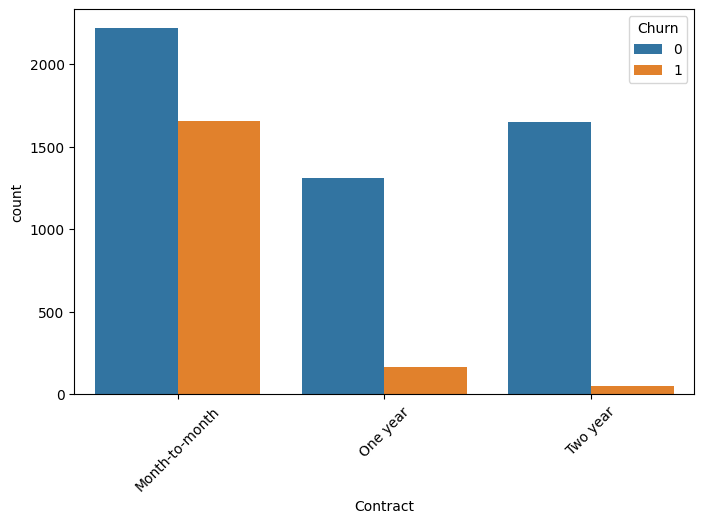

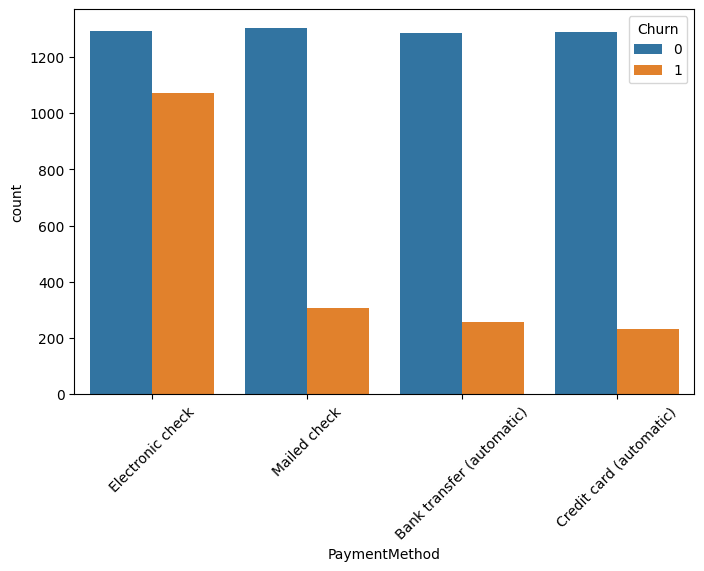

       SeniorCitizen     tenure  MonthlyCharges
Churn                                          
0                0.0  37.569965       61.265124
1                0.0  17.979133       74.441332


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.info())

print(df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df.hist(figsize=(12,10))
plt.show()

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

if 'tenure' in df.columns:
    sns.boxplot(x='Churn', y='tenure', data=df)
    plt.show()

if 'MonthlyCharges' in df.columns:
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
    plt.show()

if 'TotalCharges' in df.columns:
    sns.boxplot(x='Churn', y='TotalCharges', data=df)
    plt.show()

if 'Contract' in df.columns:
    sns.countplot(x='Contract', hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.show()

if 'PaymentMethod' in df.columns:
    sns.countplot(x='PaymentMethod', hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.show()

print(df.groupby('Churn').mean(numeric_only=True))

In [ ]:
task-2

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

/tmp/ipykernel_1464/2177136498.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(
/tmp/ipykernel_1464/2177136498.py:73: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(service_mapping)



Selected Features using RFE:
Index(['tenure', 'MultipleLines', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'TotalCharges', 'AvgMonthlySpend', 'ContractValue',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='object')

Top Feature Importance:
ContractValue                     0.164552
TotalCharges                      0.129660
tenure                            0.116174
AvgMonthlySpend                   0.115089
MonthlyCharges                    0.110051
remaining_contract_months         0.042242
PaymentMethod_Electronic check    0.032229
InternetService_Fiber optic       0.031207
ServiceCount                      0.025181
gender                            0.021128
dtype: float64


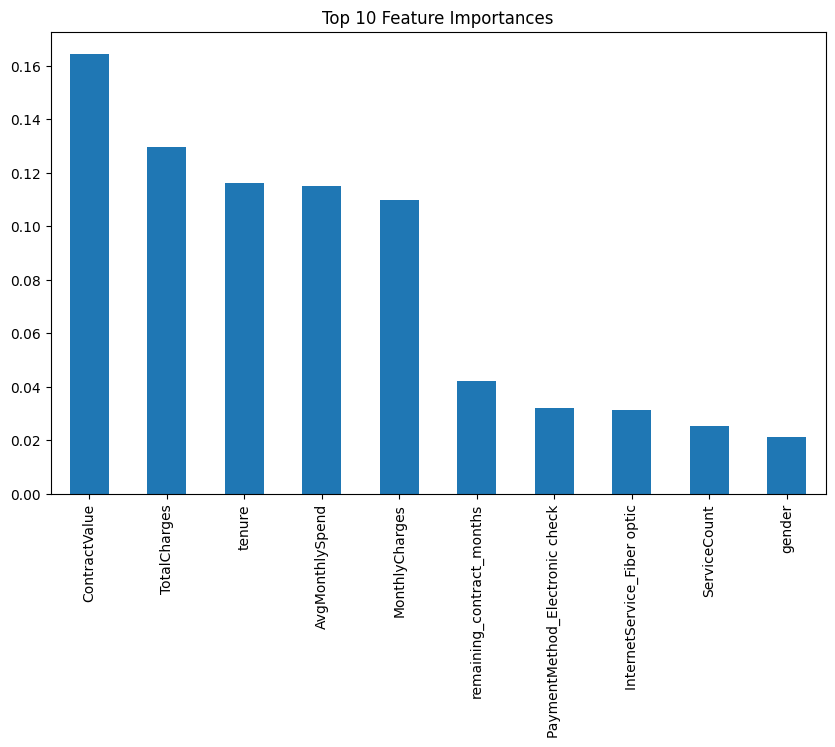


Mutual Information Scores:
ContractValue                     0.130097
remaining_contract_months         0.094739
tenure                            0.069074
Contract_Two year                 0.066356
MonthlyCharges                    0.046798
InternetService_Fiber optic       0.046075
TotalCharges                      0.043160
AvgMonthlySpend                   0.037729
PaymentMethod_Electronic check    0.037505
InternetService_No                0.029525
dtype: float64

After SMOTE:
Churn
0    5174
1    5174
Name: count, dtype: int64

After Random Undersampling:
Churn
0    1869
1    1869
Name: count, dtype: int64

Train Shape:
(7243, 27)

Validation Shape:
(1552, 27)

Test Shape:
(1553, 27)

Training Accuracy: 0.8230015187077178
Validation Accuracy: 0.8221649484536082
Test Accuracy: 0.8216355441081777


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.feature_selection import RFE
from sklearn.feature_selection import mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

le = LabelEncoder()

binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df['AvgMonthlySpend'] = (
    df['TotalCharges'] / (df['tenure'] + 1)
)

# Define a comprehensive mapping for all service-related binary features
# This map handles 'Yes', 'No', 'No internet service', and 'No phone service'
service_mapping = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0, # Covers internet-related service columns
    'No phone service': 0      # Specifically for 'MultipleLines'
}

service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines' # Added 'MultipleLines' to this list to be processed with the service_mapping
]

for col in service_cols:
    df[col] = df[col].replace(service_mapping)

df['ServiceCount'] = df[service_cols].sum(axis=1)

contract_map = {
    'Month-to-month':1,
    'One year':12,
    'Two year':24
}

df['remaining_contract_months'] = (
    df['Contract'].map(contract_map)
)

df['ContractValue'] = (
    df['MonthlyCharges'] *
    df['remaining_contract_months']
)

categorical_cols = [
    'InternetService',
    'PaymentMethod',
    'Contract'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'AvgMonthlySpend',
    'ServiceCount',
    'ContractValue'
]

standard_scaler = StandardScaler()

X_standard = X.copy()

X_standard[numerical_cols] = standard_scaler.fit_transform(
    X_standard[numerical_cols]
)

minmax_scaler = MinMaxScaler()

X_minmax = X.copy()

X_minmax[numerical_cols] = minmax_scaler.fit_transform(
    X_minmax[numerical_cols]
)

corr_matrix = X_standard.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

threshold = 0.90

drop_columns = [
    column
    for column in upper.columns
    if any(upper[column] > threshold)
]

X_filtered = X_standard.drop(
    columns=drop_columns
)

print("\nDropped Columns:")
print(drop_columns)

lr_model = LogisticRegression(max_iter=1000)

rfe = RFE(
    estimator=lr_model,
    n_features_to_select=10
)

X_rfe = rfe.fit_transform(
    X_filtered,
    y
)

selected_features = X_filtered.columns[rfe.support_]

print("\nSelected Features using RFE:")
print(selected_features)

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_filtered, y)

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_filtered.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print("\nTop Feature Importance:")
print(feature_importance.head(10))

plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind='bar')

plt.title("Top 10 Feature Importances")

plt.show()

mi_scores = mutual_info_classif(
    X_filtered,
    y
)

mi_scores = pd.Series(
    mi_scores,
    index=X_filtered.columns
)

mi_scores = mi_scores.sort_values(
    ascending=False
)

print("\nMutual Information Scores:")
print(mi_scores.head(10))

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_filtered,
    y
)

print("\nAfter SMOTE:")
print(y_smote.value_counts())

undersample = RandomUnderSampler(random_state=42)

X_under, y_under = undersample.fit_resample(
    X_filtered,
    y
)

print("\nAfter Random Undersampling:")
print(y_under.value_counts())

X_train, X_temp, y_train, y_temp = train_test_split(
    X_smote,
    y_smote,
    test_size=0.30,
    stratify=y_smote,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nTrain Shape:")
print(X_train.shape)

print("\nValidation Shape:")
print(X_val.shape)

print("\nTest Shape:")
print(X_test.shape)

final_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

final_model.fit(X_train, y_train)

train_score = final_model.score(X_train, y_train)
val_score = final_model.score(X_val, y_val)
test_score = final_model.score(X_test, y_test)

print("\nTraining Accuracy:", train_score)
print("Validation Accuracy:", val_score)
print("Test Accuracy:", test_score)

In [ ]:
task-3


Logistic Regression

Best Parameters:
{'C': 10, 'solver': 'liblinear'}

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       777
           1       0.81      0.86      0.83       776

    accuracy                           0.83      1553
   macro avg       0.83      0.83      0.83      1553
weighted avg       0.83      0.83      0.83      1553


Accuracy: 0.8287186091435931
Precision: 0.8102189781021898
Recall: 0.8582474226804123
F1 Score: 0.8335419274092616
ROC-AUC: 0.9088053443723547
Training Time: 3.0742037296295166


<Figure size 1000x800 with 0 Axes>

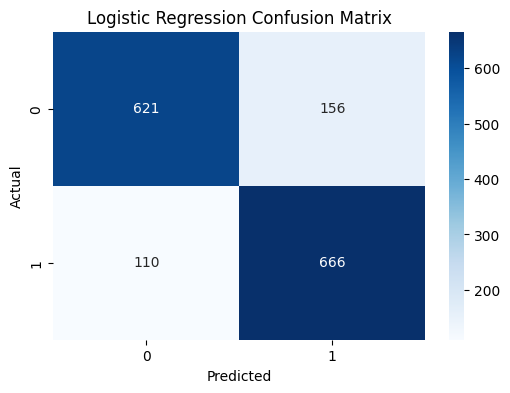


Decision Tree

Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.73      0.77       777
           1       0.75      0.83      0.79       776

    accuracy                           0.78      1553
   macro avg       0.78      0.78      0.78      1553
weighted avg       0.78      0.78      0.78      1553


Accuracy: 0.7804249839021249
Precision: 0.7537922987164527
Recall: 0.8324742268041238
F1 Score: 0.7911818738518065
ROC-AUC: 0.8351145696506521
Training Time: 5.407511949539185


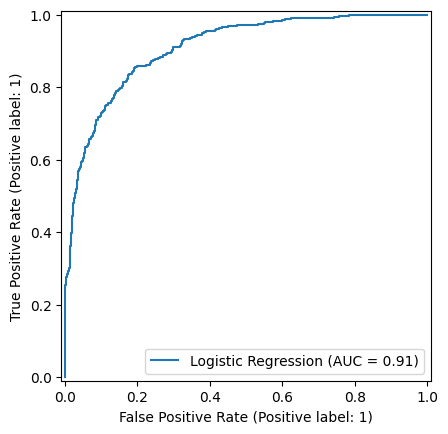

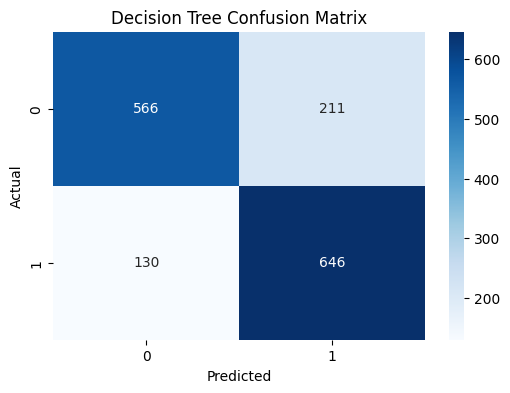


Random Forest

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       777
           1       0.82      0.86      0.84       776

    accuracy                           0.84      1553
   macro avg       0.84      0.84      0.84      1553
weighted avg       0.84      0.84      0.84      1553


Accuracy: 0.8358016741790084
Precision: 0.818070818070818
Recall: 0.8634020618556701
F1 Score: 0.8401253918495298
ROC-AUC: 0.9118636309357958
Training Time: 71.71310043334961


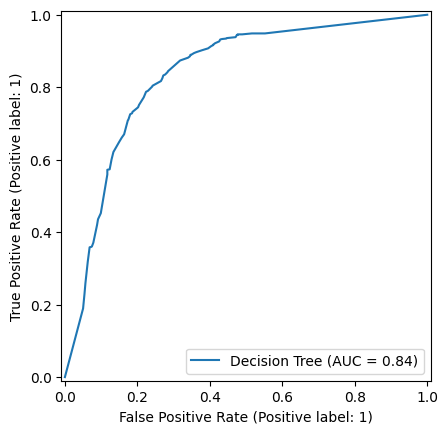

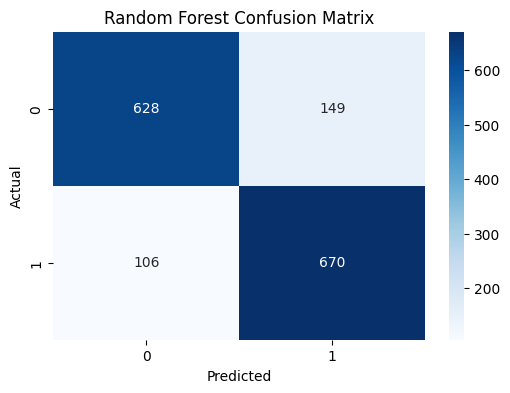


SVM

Best Parameters:
{'C': 10, 'kernel': 'linear'}

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       777
           1       0.81      0.84      0.82       776

    accuracy                           0.82      1553
   macro avg       0.82      0.82      0.82      1553
weighted avg       0.82      0.82      0.82      1553


Accuracy: 0.8209916291049582
Precision: 0.8089330024813896
Recall: 0.8402061855670103
F1 Score: 0.8242730720606827
ROC-AUC: 0.9072778595974472
Training Time: 267.8845498561859


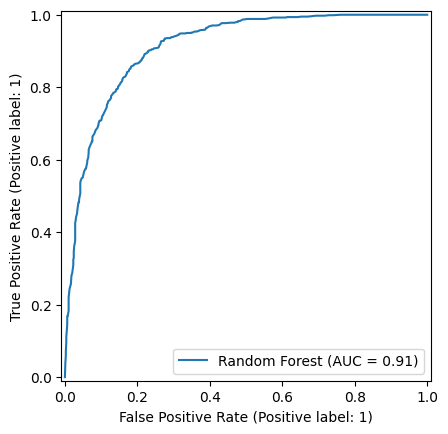

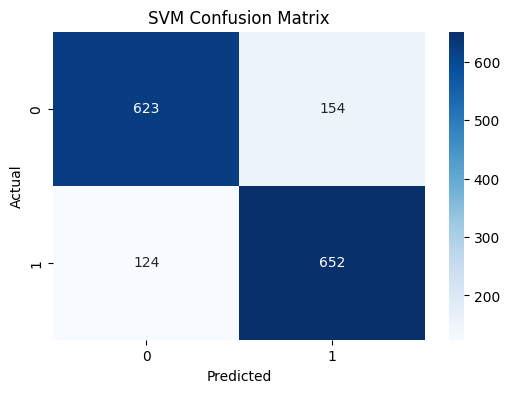


KNN

Best Parameters:
{'n_neighbors': 3, 'weights': 'uniform'}

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       777
           1       0.75      0.89      0.81       776

    accuracy                           0.80      1553
   macro avg       0.81      0.80      0.79      1553
weighted avg       0.81      0.80      0.79      1553


Accuracy: 0.7952350289761752
Precision: 0.7494553376906318
Recall: 0.8865979381443299
F1 Score: 0.8122786304604487
ROC-AUC: 0.8627991946290916
Training Time: 2.7768571376800537


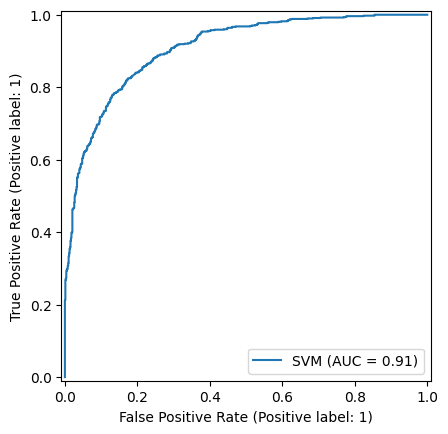

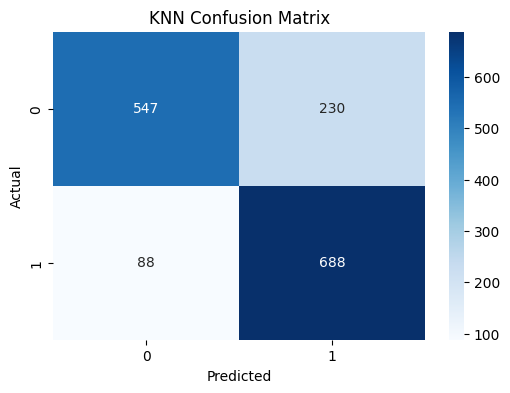

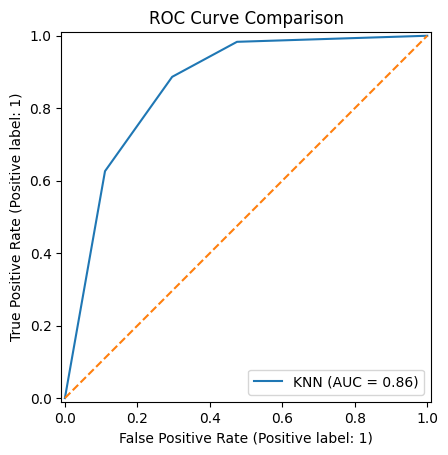


Final Comparison Table
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC  \
0  Logistic Regression  0.828719   0.810219  0.858247  0.833542  0.908805   
1        Decision Tree  0.780425   0.753792  0.832474  0.791182  0.835115   
2        Random Forest  0.835802   0.818071  0.863402  0.840125  0.911864   
3                  SVM  0.820992   0.808933  0.840206  0.824273  0.907278   
4                  KNN  0.795235   0.749455  0.886598  0.812279  0.862799   

   Training_Time  
0       3.074204  
1       5.407512  
2      71.713100  
3     267.884550  
4       2.776857  

Top 10 Important Features
ContractValue                     0.182330
tenure                            0.108011
remaining_contract_months         0.099871
MonthlyCharges                    0.073651
TotalCharges                      0.072757
AvgMonthlySpend                   0.071230
PaymentMethod_Electronic check    0.061548
Contract_Two year                 0.047665
InternetService_Fiber optic 

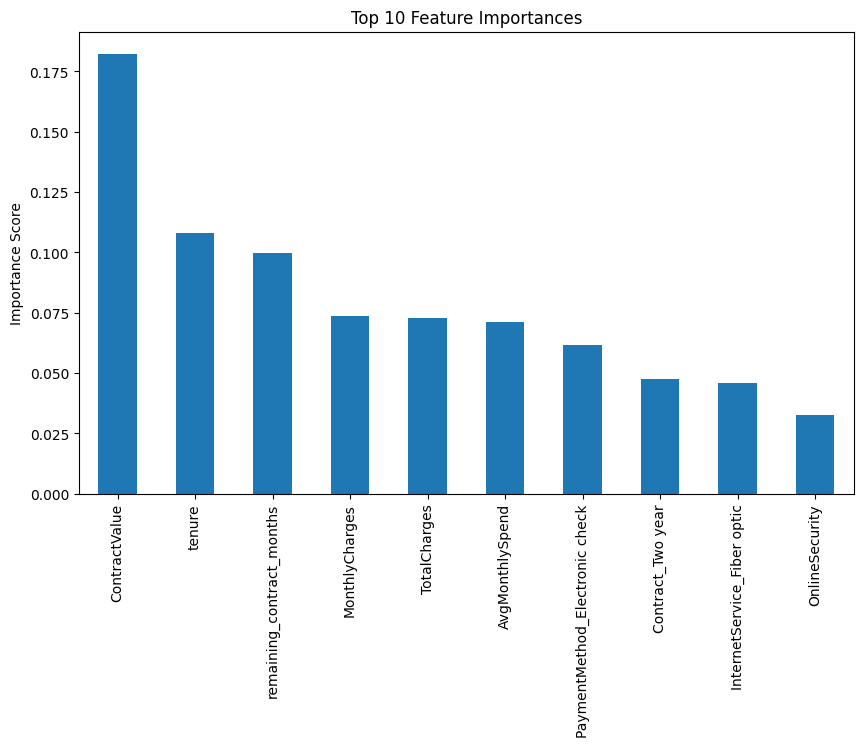

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import time

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['liblinear']
        }
    ),

    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]
        }
    ),

    "SVM": (
        SVC(probability=True),
        {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }
    )
}

results = []

plt.figure(figsize=(10,8))

for name, (model, params) in models.items():

    print(f"\n{name}")
    print("="*50)

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    start_time = time.time()

    grid.fit(X_train, y_train)

    end_time = time.time()

    best_model = grid.best_estimator_

    print("\nBest Parameters:")
    print(grid.best_params_)

    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:,1]
    else:
        y_prob = best_model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    training_time = end_time - start_time

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nAccuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)
    print("Training Time:", training_time)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    RocCurveDisplay.from_estimator(
        best_model,
        X_test,
        y_test,
        name=name
    )

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC_AUC': roc_auc,
        'Training_Time': training_time
    })

plt.title("ROC Curve Comparison")

plt.plot([0,1], [0,1], linestyle='--')

plt.show()

results_df = pd.DataFrame(results)

print("\nFinal Comparison Table")

print(results_df)

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

best_rf.fit(X_train, y_train)

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_filtered.columns
)

importance = importance.sort_values(
    ascending=False
)

print("\nTop 10 Important Features")

print(importance.head(10))

plt.figure(figsize=(10,6))

importance.head(10).plot(kind='bar')

plt.title("Top 10 Feature Importances")

plt.ylabel("Importance Score")

plt.show()

In [ ]:
task-4


Linear Regression

Best Parameters:
{}

MAE: 0.7888020562108191
MSE: 1.1001662510594488
RMSE: 1.0488881022585053
R2: 0.9987848496931273
Adjusted R2: 0.9987610922287641
Training Time: 0.16263484954833984


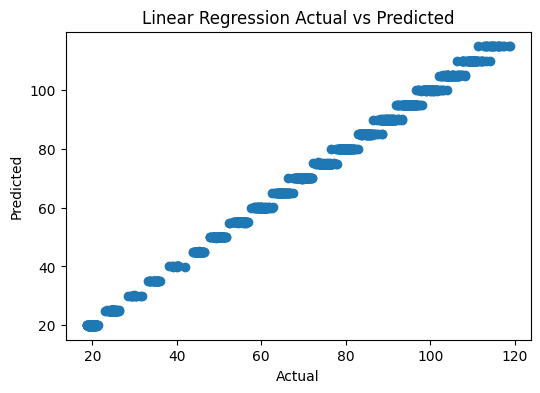


Ridge

Best Parameters:
{'alpha': 0.1}

MAE: 0.7888050461139257
MSE: 1.1001541021994792
RMSE: 1.0488823109384005
R2: 0.9987848631117274
Adjusted R2: 0.998761105909712
Training Time: 0.38443684577941895


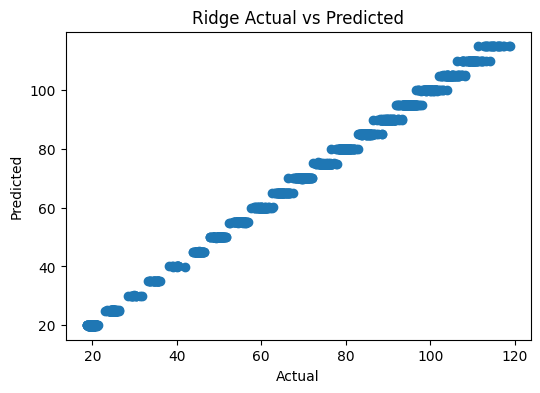


Lasso

Best Parameters:
{'alpha': 0.01}

MAE: 0.787215855425692
MSE: 1.0989896563245496
RMSE: 1.0483270750698703
R2: 0.9987861492598535
Adjusted R2: 0.9987624172033843
Training Time: 3.4091789722442627


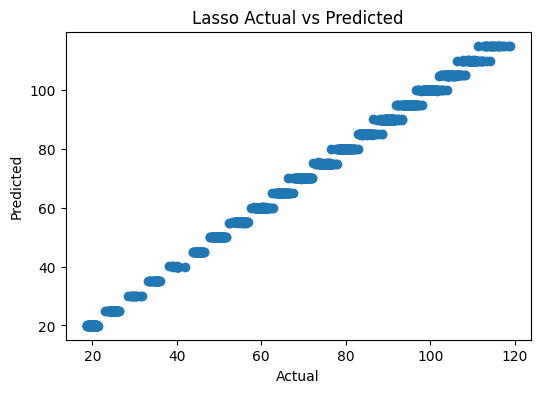


ElasticNet

Best Parameters:
{'alpha': 0.01, 'l1_ratio': 0.8}

MAE: 0.7889617055918343
MSE: 1.1008667902366127
RMSE: 1.0492219928292643
R2: 0.9987840759369834
Adjusted R2: 0.9987603033448752
Training Time: 5.986485481262207


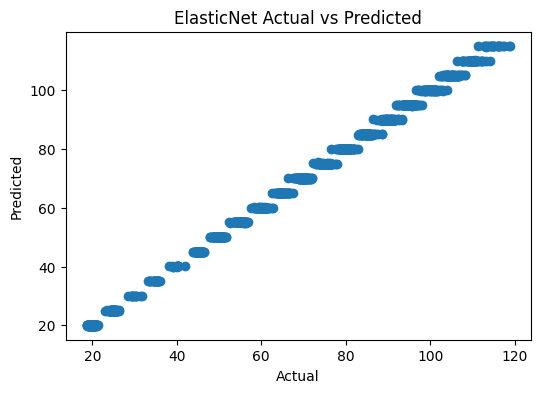


Decision Tree

Best Parameters:
{'max_depth': None, 'min_samples_split': 5}

MAE: 0.6224420392713511
MSE: 1.9016218284244142
RMSE: 1.3789930487222966
R2: 0.9978996298549055
Adjusted R2: 0.9978585654132563
Training Time: 3.83892822265625


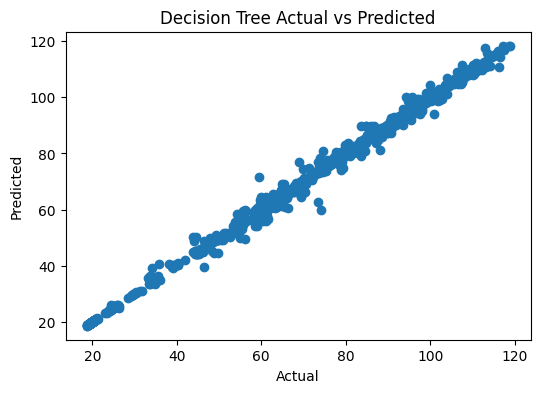


Random Forest

Best Parameters:
{'max_depth': None, 'n_estimators': 200}

MAE: 0.45359244144784067
MSE: 0.9865081859031273
RMSE: 0.9932311845200629
R2: 0.9989103867495679
Adjusted R2: 0.9988890836664674
Training Time: 111.66548109054565


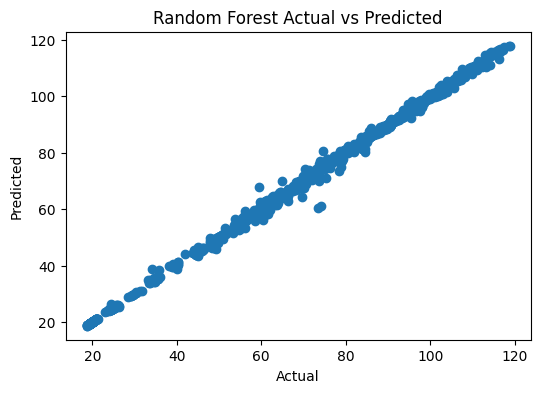


SVR

Best Parameters:
{'C': 10, 'kernel': 'linear'}

MAE: 0.7893580634344501
MSE: 1.0982286054050379
RMSE: 1.0479640286789609
R2: 0.9987869898521344
Adjusted R2: 0.9987632742301269
Training Time: 176.2410478591919


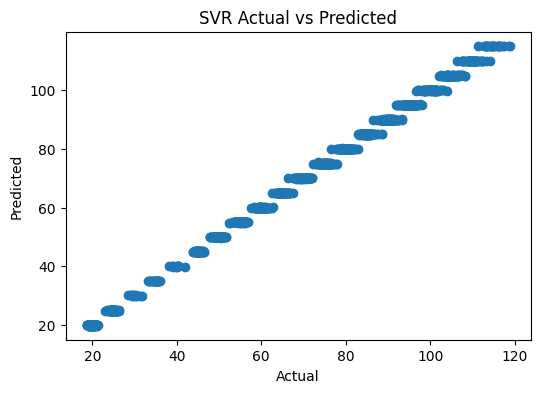


Final Comparison Table
               Model       MAE       MSE      RMSE        R2    Adj_R2  \
0  Linear Regression  0.788802  1.100166  1.048888  0.998785  0.998761   
1              Ridge  0.788805  1.100154  1.048882  0.998785  0.998761   
2              Lasso  0.787216  1.098990  1.048327  0.998786  0.998762   
3         ElasticNet  0.788962  1.100867  1.049222  0.998784  0.998760   
4      Decision Tree  0.622442  1.901622  1.378993  0.997900  0.997859   
5      Random Forest  0.453592  0.986508  0.993231  0.998910  0.998889   
6                SVR  0.789358  1.098229  1.047964  0.998787  0.998763   

   Training_Time  
0       0.162635  
1       0.384437  
2       3.409179  
3       5.986485  
4       3.838928  
5     111.665481  
6     176.241048  


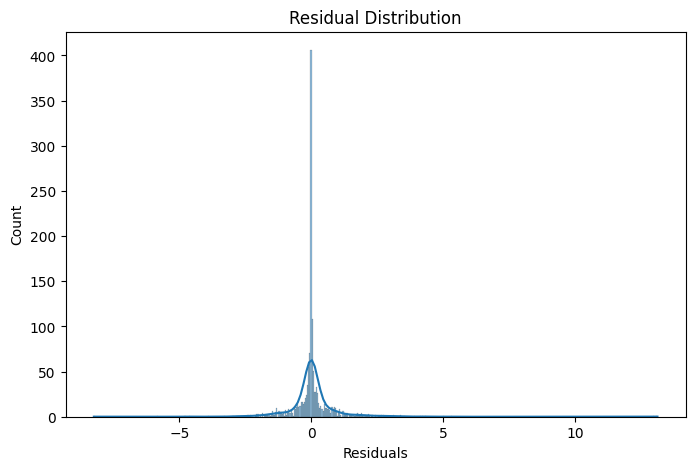


Top Feature Importances
AvgMonthlySpend                0.902295
InternetService_Fiber optic    0.033534
InternetService_No             0.032731
ContractValue                  0.010759
ServiceCount                   0.007195
tenure                         0.005328
PhoneService                   0.005040
TotalCharges                   0.001437
MultipleLines                  0.000555
StreamingMovies                0.000215
dtype: float64


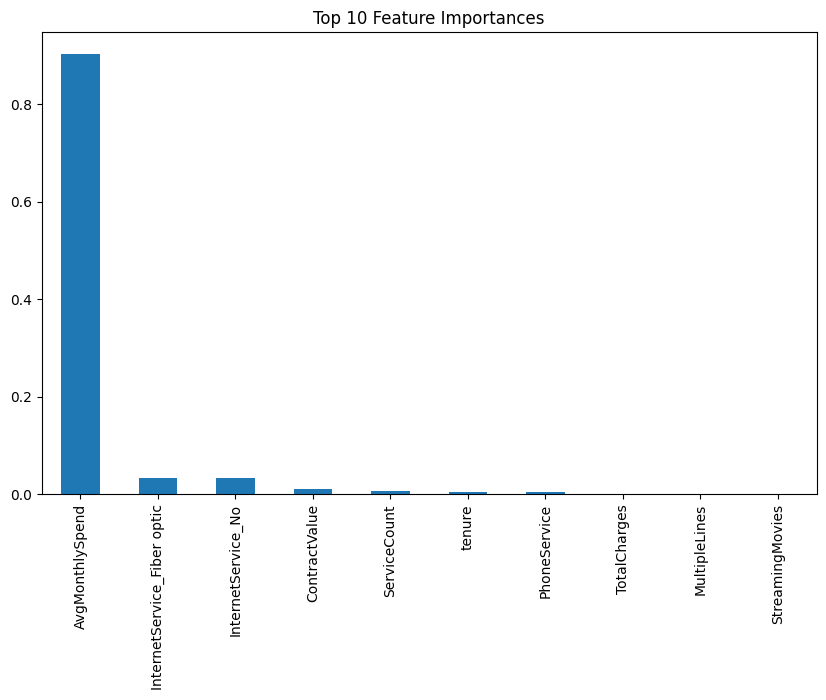


Linear Regression Top Coefficients
InternetService_Fiber optic    12.358601
InternetService_No            -10.280035
PhoneService                    5.944231
StreamingTV                     3.988974
StreamingMovies                 3.977429
ServiceCount                    3.632977
MultipleLines                   1.597622
DeviceProtection                1.530657
OnlineBackup                    1.520611
OnlineSecurity                  1.472078
dtype: float64

Ridge Top Coefficients
InternetService_Fiber optic    12.354522
InternetService_No            -10.275984
PhoneService                    5.942458
StreamingTV                     3.988212
StreamingMovies                 3.976598
ServiceCount                    3.632514
MultipleLines                   1.597965
DeviceProtection                1.530607
OnlineBackup                    1.520373
OnlineSecurity                  1.471806
dtype: float64

Lasso Top Coefficients
InternetService_Fiber optic    12.358851
InternetService_No       

In [5]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

import time

y_reg = df['MonthlyCharges']

X_reg = df.drop('MonthlyCharges', axis=1)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(X_train_reg)

X_test_reg_scaled = scaler.transform(X_test_reg)

reg_models = {
    "Linear Regression": (
        LinearRegression(),
        {}
    ),

    "Ridge": (
        Ridge(),
        {
            'alpha': [0.01, 0.1, 1, 10]
        }
    ),

    "Lasso": (
        Lasso(),
        {
            'alpha': [0.001, 0.01, 0.1, 1]
        }
    ),

    "ElasticNet": (
        ElasticNet(),
        {
            'alpha': [0.001, 0.01, 0.1],
            'l1_ratio': [0.2, 0.5, 0.8]
        }
    ),

    "Decision Tree": (
        DecisionTreeRegressor(random_state=42),
        {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10]
        }
    ),

    "Random Forest": (
        RandomForestRegressor(random_state=42),
        {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None]
        }
    ),

    "SVR": (
        SVR(),
        {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
    )
}

regression_results = []

best_model = None

best_r2 = -1

for name, (model, params) in reg_models.items():

    print(f"\n{name}")
    print("="*50)

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    start_time = time.time()

    if name in ['SVR', 'Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']:
        grid.fit(X_train_reg_scaled, y_train_reg)
        y_pred = grid.best_estimator_.predict(X_test_reg_scaled)
    else:
        grid.fit(X_train_reg, y_train_reg)
        y_pred = grid.best_estimator_.predict(X_test_reg)

    end_time = time.time()

    mae = mean_absolute_error(y_test_reg, y_pred)

    mse = mean_squared_error(y_test_reg, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test_reg, y_pred)

    n = len(y_test_reg)

    p = X_reg.shape[1]

    adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

    training_time = end_time - start_time

    print("\nBest Parameters:")
    print(grid.best_params_)

    print("\nMAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("Adjusted R2:", adj_r2)
    print("Training Time:", training_time)

    plt.figure(figsize=(6,4))

    plt.scatter(y_test_reg, y_pred)

    plt.xlabel("Actual")

    plt.ylabel("Predicted")

    plt.title(f"{name} Actual vs Predicted")

    plt.show()

    regression_results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adj_R2': adj_r2,
        'Training_Time': training_time
    })

    if r2 > best_r2:
        best_r2 = r2
        best_model = grid.best_estimator_
        best_predictions = y_pred

results_reg_df = pd.DataFrame(regression_results)

print("\nFinal Comparison Table")

print(results_reg_df)

residuals = y_test_reg - best_predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residuals")

plt.show()

if hasattr(best_model, 'feature_importances_'):

    importance = pd.Series(
        best_model.feature_importances_,
        index=X_reg.columns
    )

    importance = importance.sort_values(
        ascending=False
    )

    print("\nTop Feature Importances")

    print(importance.head(10))

    plt.figure(figsize=(10,6))

    importance.head(10).plot(kind='bar')

    plt.title("Top 10 Feature Importances")

    plt.show()

linear_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

for name, model in linear_models.items():

    model.fit(X_train_reg_scaled, y_train_reg)

    coefficients = pd.Series(
        model.coef_,
        index=X_reg.columns
    )

    coefficients = coefficients.sort_values(
        key=abs,
        ascending=False
    )

    print(f"\n{name} Top Coefficients")

    print(coefficients.head(10))

In [ ]:
task-5


SHAP Summary Plot


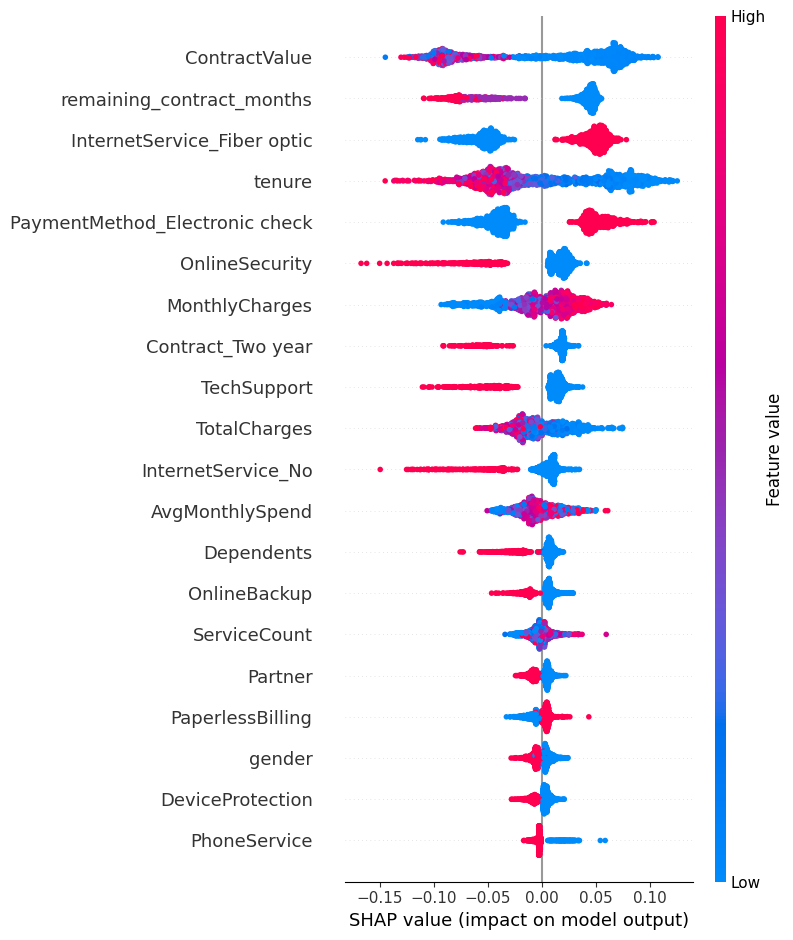


Local Explanation - Churned Customer


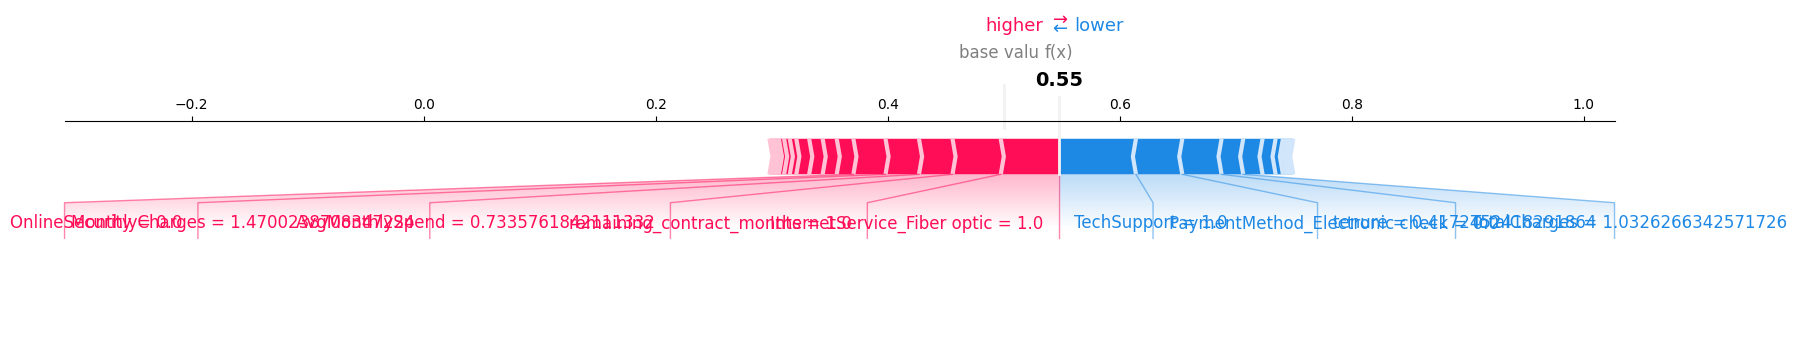


Local Explanation - Retained Customer


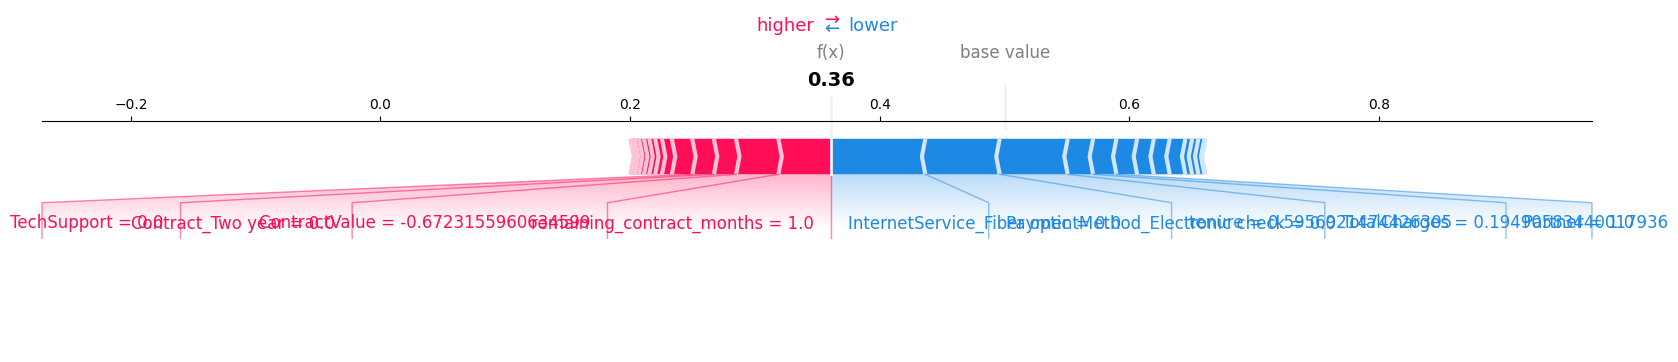


Partial Dependence Plot for ContractValue


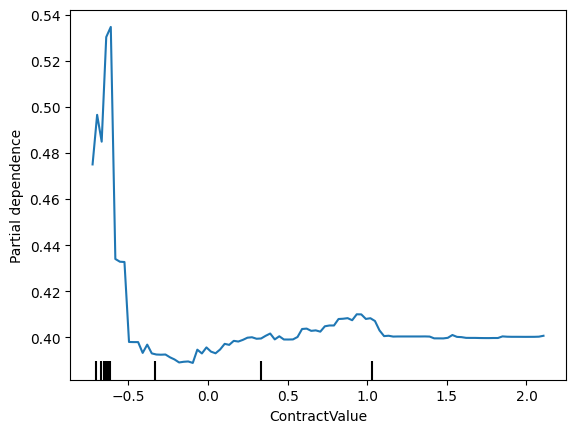


Partial Dependence Plot for TotalCharges


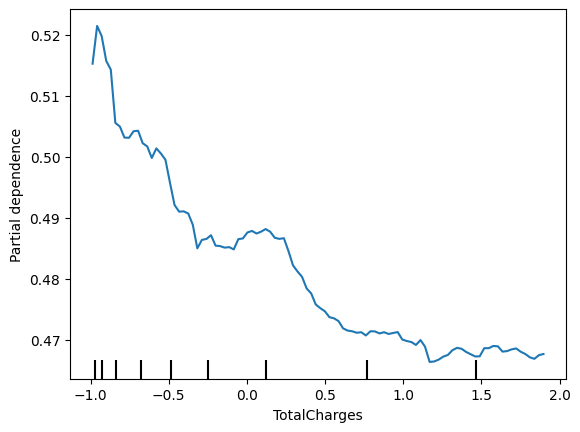


Partial Dependence Plot for tenure


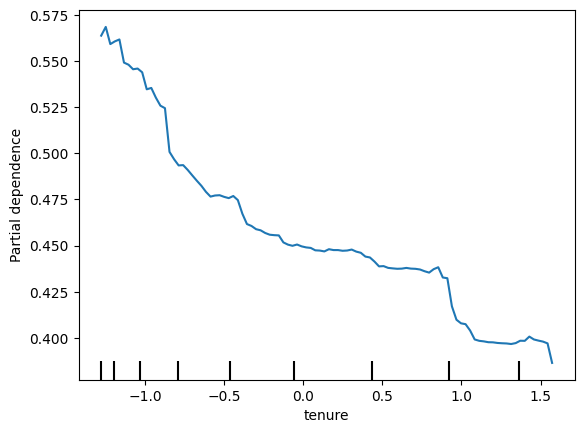


Top 5 Churn Drivers
                           Feature  Importance
19                   ContractValue    0.063729
18       remaining_contract_months    0.052003
20     InternetService_Fiber optic    0.052002
4                           tenure    0.051652
23  PaymentMethod_Electronic check    0.047220

Top High Risk Customers
      Predicted_Probability  Actual_Churn
1976               0.966713             1
9925               0.959348             1
4585               0.954250             1
9259               0.953361             1
8857               0.950361             1
8373               0.950126             1
5474               0.948409             0
8335               0.947785             1
8808               0.947687             1
4084               0.947187             1

Cost Benefit Analysis
Retention Campaign Cost: 5000
Estimated Revenue Saved: 46500
ROI Percentage: 830.0000000000001

Random Targeting ROI
399.6780424983902

Model Based ROI
830.0000000000001


In [7]:
import shap

from sklearn.inspection import PartialDependenceDisplay

best_clf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

best_clf_model.fit(X_train, y_train)

y_prob = best_clf_model.predict_proba(X_test)[:,1]

y_pred = best_clf_model.predict(X_test)

explainer = shap.TreeExplainer(best_clf_model)

shap_values = explainer.shap_values(X_test)

print("\nSHAP Summary Plot")


shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

churned_index = np.where(y_test == 1)[0][0]

retained_index = np.where(y_test == 0)[0][0]

print("\nLocal Explanation - Churned Customer")

# Corrected: Access SHAP values for the specific churned sample for the positive class
shap.force_plot(
    explainer.expected_value[1],
    shap_values[churned_index, :, 1],
    X_test.iloc[churned_index],
    matplotlib=True
)

print("\nLocal Explanation - Retained Customer")

# Corrected: Access SHAP values for the specific retained sample for the positive class
shap.force_plot(
    explainer.expected_value[1],
    shap_values[retained_index, :, 1],
    X_test.iloc[retained_index],
    matplotlib=True
)

top_features = feature_importance.head(3).index.tolist()

for feature in top_features:

    print(f"\nPartial Dependence Plot for {feature}")

    PartialDependenceDisplay.from_estimator(
        best_clf_model,
        X_test,
        [feature]
    )

    plt.show()

# Corrected: Calculate mean absolute SHAP values for each feature for the positive class
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': np.abs(shap_values[:, :, 1]).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 5 Churn Drivers")

print(shap_importance.head(5))

high_risk_customers = X_test.copy()

high_risk_customers['Actual_Churn'] = y_test.values

high_risk_customers['Predicted_Probability'] = y_prob

high_risk_customers = high_risk_customers.sort_values(
    by='Predicted_Probability',
    ascending=False
)

print("\nTop High Risk Customers")

print(
    high_risk_customers[
        ['Predicted_Probability', 'Actual_Churn']
    ].head(10)
)

top_100_customers = high_risk_customers.head(100)

expected_saved_customers = top_100_customers[
    top_100_customers['Actual_Churn'] == 1
].shape[0]

retention_cost = 100 * 50

saved_revenue = expected_saved_customers * 500

roi = (
    (saved_revenue - retention_cost)
    / retention_cost
) * 100

print("\nCost Benefit Analysis")

print("Retention Campaign Cost:", retention_cost)

print("Estimated Revenue Saved:", saved_revenue)

print("ROI Percentage:", roi)

random_targeting_expected = (
    y_test.mean() * 100
)

random_saved_revenue = (
    random_targeting_expected * 500
)

random_roi = (
    (random_saved_revenue - retention_cost)
    / retention_cost
) * 100

print("\nRandom Targeting ROI")

print(random_roi)

print("\nModel Based ROI")

print(roi)